<a href="https://colab.research.google.com/github/delishashibu28-bot/Adult-census-income-classification/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement
Context: Government agencies, financial institutions, and social researchers often need to understand the socio-economic factors that drive individual income levels. Predicting income brackets helps in optimizing tax policies, targeting social welfare programs, and understanding economic inequality.

The Problem: Given a diverse set of demographic and socio-economic indicators—such as age, education level, marital status, occupation, race, gender, and weekly working hours—the goal is to build a robust machine learning model that accurately classifies whether an individual's annual income exceeds $50,000.

Objective: To develop and evaluate predictive classification models (e.g., Logistic Regression, Decision Trees, Random Forests) that can identify the most significant predictors of high income, minimize misclassification, and provide insights into demographic wage disparities.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/adult.csv")

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [ ]:
df.replace('?',np.nan,inplace=True)

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.dropna(axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
fnlwgt,0
education,0
education.num,0
marital.status,0
relationship,0
race,0
sex,0
capital.gain,0
capital.loss,0


In [ ]:
df

,age,fnlwgt,education,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,77053,HS-grad,9,Widowed,Not-in-family,White,Female,0,4356,40,<=50K
1,82,132870,HS-grad,9,Widowed,Not-in-family,White,Female,0,4356,18,<=50K
2,66,186061,Some-college,10,Widowed,Unmarried,Black,Female,0,4356,40,<=50K
3,54,140359,7th-8th,4,Divorced,Unmarried,White,Female,0,3900,40,<=50K
4,41,264663,Some-college,10,Separated,Own-child,White,Female,0,3900,40,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,Some-college,10,Never-married,Not-in-family,White,Male,0,0,40,<=50K
32557,27,257302,Assoc-acdm,12,Married-civ-spouse,Wife,White,Female,0,0,38,<=50K
32558,40,154374,HS-grad,9,Married-civ-spouse,Husband,White,Male,0,0,40,>50K
32559,58,151910,HS-grad,9,Widowed,Unmarried,White,Female,0,0,40,<=50K


In [ ]:
df.duplicated().sum()

np.int64(94)

In [ ]:
df.shape

(32561, 12)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(32467, 12)

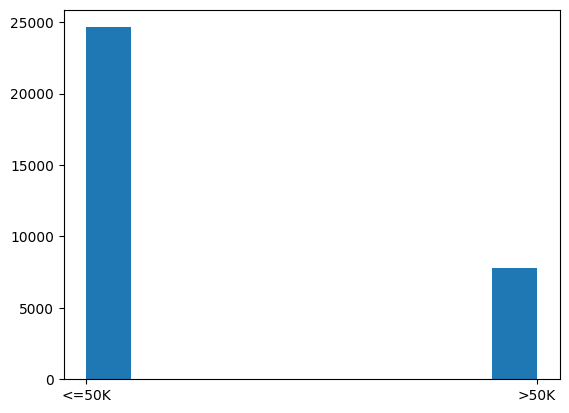

In [ ]:
plt.hist(df["income"])
plt.show()

In [ ]:
df

,age,fnlwgt,education,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,77053,HS-grad,9,Widowed,Not-in-family,White,Female,0,4356,40,<=50K
1,82,132870,HS-grad,9,Widowed,Not-in-family,White,Female,0,4356,18,<=50K
2,66,186061,Some-college,10,Widowed,Unmarried,Black,Female,0,4356,40,<=50K
3,54,140359,7th-8th,4,Divorced,Unmarried,White,Female,0,3900,40,<=50K
4,41,264663,Some-college,10,Separated,Own-child,White,Female,0,3900,40,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
32555,53,321865,Masters,14,Married-civ-spouse,Husband,White,Male,0,0,40,>50K
32557,27,257302,Assoc-acdm,12,Married-civ-spouse,Wife,White,Female,0,0,38,<=50K
32558,40,154374,HS-grad,9,Married-civ-spouse,Husband,White,Male,0,0,40,>50K
32559,58,151910,HS-grad,9,Widowed,Unmarried,White,Female,0,0,40,<=50K


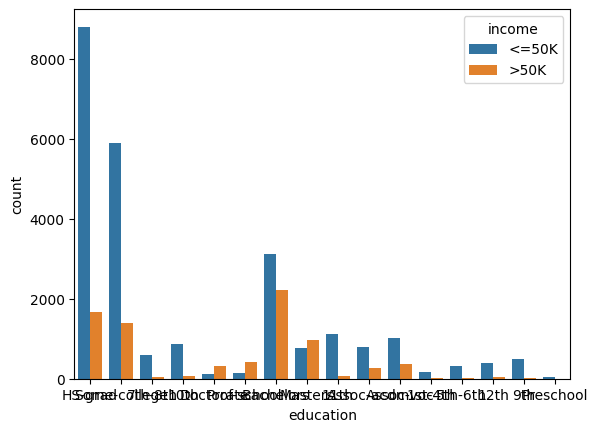

In [ ]:
sns.countplot(data=df, x='education', hue='income')
plt.show()

In [ ]:
df.head()

,age,fnlwgt,education,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,77053,HS-grad,9,Widowed,Not-in-family,White,Female,0,4356,40,<=50K
1,82,132870,HS-grad,9,Widowed,Not-in-family,White,Female,0,4356,18,<=50K
2,66,186061,Some-college,10,Widowed,Unmarried,Black,Female,0,4356,40,<=50K
3,54,140359,7th-8th,4,Divorced,Unmarried,White,Female,0,3900,40,<=50K
4,41,264663,Some-college,10,Separated,Own-child,White,Female,0,3900,40,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32467 entries, 0 to 32560
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32467 non-null  int64 
 1   fnlwgt          32467 non-null  int64 
 2   education       32467 non-null  object
 3   education.num   32467 non-null  int64 
 4   marital.status  32467 non-null  object
 5   relationship    32467 non-null  object
 6   race            32467 non-null  object
 7   sex             32467 non-null  object
 8   capital.gain    32467 non-null  int64 
 9   capital.loss    32467 non-null  int64 
 10  hours.per.week  32467 non-null  int64 
 11  income          32467 non-null  object
dtypes: int64(6), object(6)
memory usage: 3.2+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['marital.status']=le.fit_transform(df['marital.status'])
df['relationship'] = le.fit_transform(df['relationship'])
df['race']=le.fit_transform(df['race'])
df['sex'] = le.fit_transform(df['sex'])
df['income'] = le.fit_transform(df['income'])

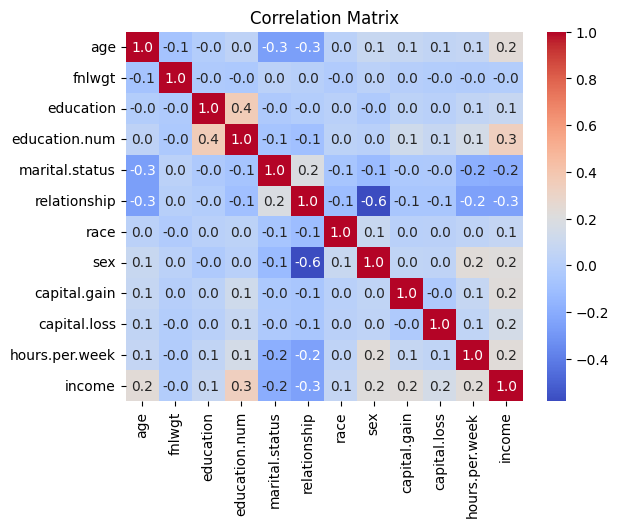

In [ ]:
corr_matrix = df.corr()

sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df

,age,fnlwgt,education,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,77053,11,9,6,1,4,0,0,4356,40,0
1,82,132870,11,9,6,1,4,0,0,4356,18,0
2,66,186061,15,10,6,4,2,0,0,4356,40,0
3,54,140359,5,4,0,4,4,0,0,3900,40,0
4,41,264663,15,10,5,3,4,0,0,3900,40,0
...,...,...,...,...,...,...,...,...,...,...,...,...
32555,53,321865,12,14,2,0,4,1,0,0,40,1
32557,27,257302,7,12,2,5,4,0,0,0,38,0
32558,40,154374,11,9,2,0,4,1,0,0,40,1
32559,58,151910,11,9,6,4,4,0,0,0,40,0


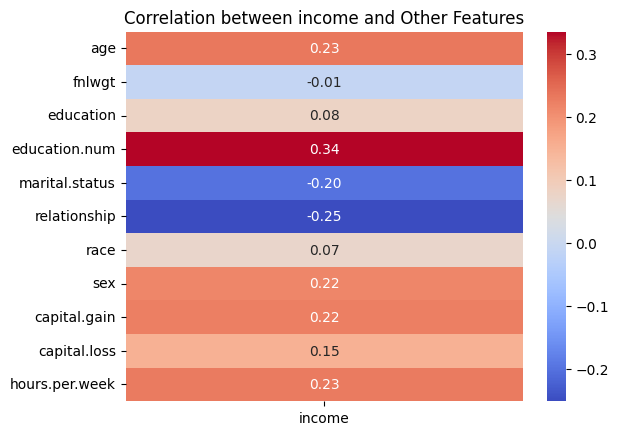

In [ ]:
income_corr = df.corr()['income']


income_corr = income_corr.drop('income')


sns.heatmap(income_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between income and Other Features')
plt.show()

In [ ]:
df.drop(["fnlwgt","education","race"],axis=1,inplace=True)

<Axes: >

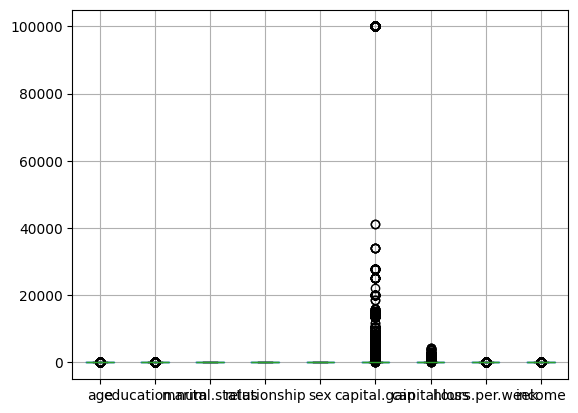

In [ ]:
df.boxplot()

In [ ]:

def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:

        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df


df_cleaned = remove_outliers_iqr(df, exclude_column='income')
df=df_cleaned

In [ ]:
df.shape

(19543, 9)

In [ ]:
df

,age,education.num,marital.status,relationship,sex,capital.gain,capital.loss,hours.per.week,income
4232,38,9,0,1,1,0,0,40,0
4233,53,7,2,0,1,0,0,40,0
4234,28,13,2,5,0,0,0,40,0
4235,37,14,2,5,0,0,0,40,0
4237,52,9,2,0,1,0,0,45,1
...,...,...,...,...,...,...,...,...,...
32553,43,11,2,0,1,0,0,45,0
32555,53,14,2,0,1,0,0,40,1
32557,27,12,2,5,0,0,0,38,0
32558,40,9,2,0,1,0,0,40,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features = ['age','education.num',	'marital.status',	'relationship',	'sex',	'capital.gain',	'capital.loss',	'hours.per.week']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pandas as pd



X = df[['age','education.num',	'marital.status',	'relationship',	'sex',	'capital.gain',	'capital.loss',	'hours.per.week']]
y = df['income']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model =DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Decision Tree accuracy: {accuracy:.2f}')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Decision Tree accuracy: 0.81
[[3543  384]
 [ 539  420]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      3927
           1       0.52      0.44      0.48       959

    accuracy                           0.81      4886
   macro avg       0.70      0.67      0.68      4886
weighted avg       0.80      0.81      0.80      4886



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd



X = df[['age','education.num',	'marital.status',	'relationship',	'sex',	'capital.gain',	'capital.loss',	'hours.per.week']]
y = df['income']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model =RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest accuracy: {accuracy:.2f}')


Random Forest accuracy: 0.82


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd



X = df[['age','education.num',	'marital.status',	'relationship',	'sex',	'capital.gain',	'capital.loss',	'hours.per.week']]
y = df['income']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model =LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'baseline model accuracy: {accuracy:.2f}')

baseline model accuracy: 0.83


#Project Conclusion
In this project, we evaluated three machine learning classification algorithms—Logistic Regression, Random Forest, and Decision Tree—to predict whether an individual's annual income exceeds $50,000 using census data. The models achieved accuracy scores of 0.83, 0.82, and 0.81, respectively.

Logistic Regression was selected as the optimal final model for this dataset, achieving the highest overall accuracy of 83%. Because the socio-economic features in this dataset likely exhibit linear relationships with income (such as education levels and age correlated with higher pay), the simpler, linear model outperformed the complex tree-based algorithms while offering better interpretability for feature importance.